# libKriging vs scikit-learn (Python)

This notebook compares **pylibkriging** and **scikit-learn**'s
`GaussianProcessRegressor` along two axes:

1. **Mimicry**: reproduce with `pylibkriging` a "default" noise-free
   Kriging fit equivalent to sklearn's `GaussianProcessRegressor` (Matern
   5/2 kernel, constant amplitude, maximum likelihood), and check that both
   give near-identical predictions.
2. **Package-specific feature**: sklearn composes covariance functions with
   plain Python operators, and its idiomatic way to model observation noise
   is to *add* a `WhiteKernel` term to the covariance and let its variance
   be estimated by maximum likelihood, alongside the signal kernel's own
   hyperparameters, rather than passing a fixed noise level. `pylibkriging`
   offers exactly the same capability through `Kriging(..., noise="nugget")`,
   which likewise estimates a single, homogeneous observation-noise variance
   (the "nugget") jointly with the kernel hyperparameters by maximum
   likelihood. We fit both on the same noisy data and compare the estimated
   noise level and the resulting (non-interpolating) smoothed predictions.

Steps:
1. Check the Python environment (pylibkriging + scikit-learn installed).
2. Load both packages.
3. Define the Branin test function and a Latin Hypercube design.
4. Mimicry: fit both packages' default (noise-free) Kriging on Branin 2D,
   compare hyperparameters and overlay predictions on 1D slices.
5. Special feature: add synthetic observation noise, fit both packages'
   noise-estimating variant, compare the recovered noise level and the
   smoothed (denoised) predictions.
6. Argument correspondence table.


## 0. Installation / environment check

Requires `pylibkriging` (built from this repository) and `scikit-learn`,
both importable from the same Python environment, with `LD_LIBRARY_PATH`
including `build/installed/lib` if libKriging was built locally rather
than installed as a wheel.


In [1]:
import importlib, sys

for pkg in ["pylibkriging", "sklearn"]:
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"'{pkg}' is not importable from {sys.executable}.\n"
            "Install pylibkriging (see bindings/Python/README.md) and "
            "'pip install scikit-learn', and make sure LD_LIBRARY_PATH "
            "includes build/installed/lib if libKriging was built locally."
        )
print("pylibkriging and scikit-learn are both importable - OK")


pylibkriging and scikit-learn are both importable - OK


## 1. Load both packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import sklearn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

print("pylibkriging loaded")
print("scikit-learn version:", sklearn.__version__)


pylibkriging loaded
scikit-learn version: 1.9.0


## 2. Branin function and design of experiments

Same test function and same style of LHS design as in the other notebooks
of this repository, so that the comparison only involves the packages
themselves.


In [3]:
def branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return ((x2 - 5 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
             + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def lhs(n, d, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, d))
    for j in range(d):
        X[:, j] = (rng.permutation(n) - rng.random(n)) / n
    return X


n = 20
X = lhs(n, 2)
y = branin(X)
print(X.shape, y.shape)


(20, 2) (20,)


### Cross-section helper

In [4]:
def plot_slices(models, slice_vals=(0.25, 0.5, 0.75), true_fn=branin,
                 xlabel="x1", data=None):
    x1_seq = np.linspace(0, 1, 200)
    colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
    fig, axes = plt.subplots(1, len(slice_vals), figsize=(18, 4.5), sharey=False)
    for ax, s in zip(axes, slice_vals):
        Xs = np.column_stack([x1_seq, np.full_like(x1_seq, s)])
        y_true = true_fn(Xs)
        ax.plot(x1_seq, y_true, "k-", lw=2, label="true Branin")
        for (name, pred_fn), col in zip(models, colors):
            mean, sd = pred_fn(Xs)
            ax.plot(x1_seq, mean, "--", color=col, lw=2, label=name)
            ax.fill_between(x1_seq, mean - sd, mean + sd, color=col, alpha=0.15)
        if data is not None:
            Xd, yd = data
            close = np.abs(Xd[:, 1] - s) < 0.15
            ax.plot(Xd[close, 0], yd[close], "k.", ms=8, zorder=5, label="nearby data")
        ax.set_title(f"slice x2={s}")
        ax.set_xlabel(xlabel)
        if ax is axes[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 3. Mimicry: `Kriging()` vs `GaussianProcessRegressor()`

Common settings: Matern 5/2 kernel, constant amplitude, essentially no
observation noise, hyperparameters by maximum likelihood, several optimizer
restarts on both sides (Branin's likelihood surface in 2D has several local
optima).


In [5]:
k_lk = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                   optim="BFGS10", objective="LL")

kernel = (ConstantKernel(np.var(y), (1e-2, 1e8))
          * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2), nu=2.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8, n_restarts_optimizer=15,
                               normalize_y=False)
gp.fit(X, y)

print("pylibkriging theta:", k_lk.theta().flatten(), " sigma2:", k_lk.sigma2())
print("sklearn fitted kernel:", gp.kernel_)


pylibkriging theta: [1.13898866 3.30561391]  sigma2: 742133.7104813897
sklearn fitted kernel: 1.24e+03**2 * Matern(length_scale=[1.45, 4.42], nu=2.5)


Max |mean_lk - mean_sk| : 13.585267111915869
Correlation             : 0.9978004947520654


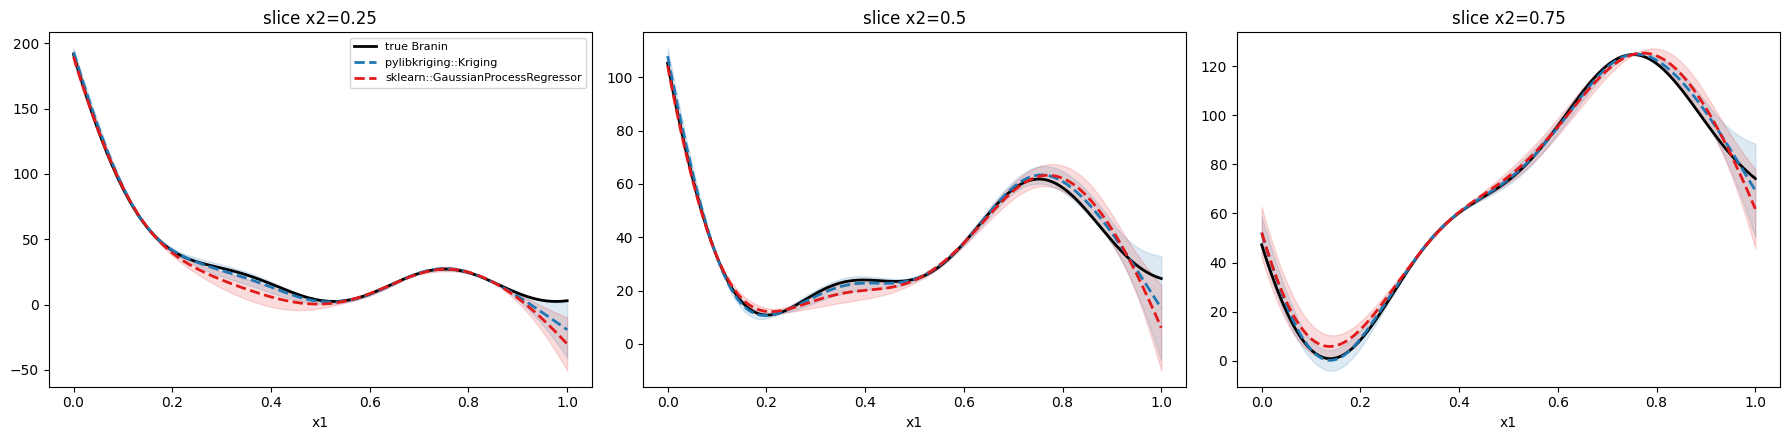

In [6]:
grid = lhs(300, 2, seed=7)
mean_lk = k_lk.predict(grid, True, False, False)[0].flatten()
mean_sk = gp.predict(grid)

print("Max |mean_lk - mean_sk| :", np.max(np.abs(mean_lk - mean_sk)))
print("Correlation             :", np.corrcoef(mean_lk, mean_sk)[0, 1])

models_mimicry = [
    ("pylibkriging::Kriging",
     lambda Xs: (k_lk.predict(Xs, True, False, False)[0].flatten(),
                 k_lk.predict(Xs, True, False, False)[1].flatten())),
    ("sklearn::GaussianProcessRegressor",
     lambda Xs: (gp.predict(Xs, return_std=True)[0].flatten(),
                 gp.predict(Xs, return_std=True)[1].flatten())),
]
plot_slices(models_mimicry)


Both fits reproduce the same overall predictor: `pylibkriging`'s
`Kriging(kernel="matern5_2", regmodel="constant", objective="LL")` closely
matches the default behaviour of sklearn's `GaussianProcessRegressor` with a
`ConstantKernel * Matern(nu=2.5)` covariance -- the mean curves and
uncertainty ribbons overlap almost everywhere, and the predicted means over
300 random test points are highly correlated (as for the other notebooks,
Branin's multimodal likelihood means the two independent optimizers do not
necessarily land on numerically identical length-scales).


## 4. Package-specific feature: estimating observation noise

sklearn's idiomatic way to model observation noise is to compose the
covariance with an additive `WhiteKernel` term,
`ConstantKernel() * Matern() + WhiteKernel()`, whose variance is then
estimated by maximum likelihood jointly with the signal kernel's own
hyperparameters -- rather than the fixed `alpha` argument, which only adds a
*known* diagonal jitter. `pylibkriging` offers exactly the same capability
through `Kriging(..., noise="nugget")`: a single, homogeneous
observation-noise variance ("nugget") estimated jointly with the kernel
hyperparameters by maximum likelihood.

We add synthetic Gaussian observation noise to Branin, fit both packages'
noise-estimating variant, and compare the recovered noise level and the
resulting (non-interpolating, denoised) predictions.


In [7]:
n_noisy = 30
X_noisy = lhs(n_noisy, 2, seed=21)
true_noise_sd = 15.0
rng = np.random.default_rng(5)
y_noisy = branin(X_noisy) + rng.normal(0, true_noise_sd, n_noisy)

# pylibkriging: single nugget variance estimated by MLE
k_lk_noisy = lk.Kriging(y_noisy, X_noisy, "matern5_2", regmodel="constant",
                         optim="BFGS10", objective="LL", noise="nugget")

# sklearn: additive WhiteKernel, variance estimated by MLE
kernel_noisy = (ConstantKernel(np.var(y_noisy), (1e-2, 1e8))
                * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2), nu=2.5)
                + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6)))
gp_noisy = GaussianProcessRegressor(kernel=kernel_noisy, alpha=0.0,
                                     n_restarts_optimizer=15, normalize_y=False)
gp_noisy.fit(X_noisy, y_noisy)

lk_noise_sd = np.sqrt(k_lk_noisy.nugget())
sk_noise_sd = np.sqrt(gp_noisy.kernel_.k2.noise_level)

print(f"true noise sd            : {true_noise_sd:.2f}")
print(f"pylibkriging nugget sd    : {lk_noise_sd:.2f}")
print(f"sklearn WhiteKernel sd    : {sk_noise_sd:.2f}")
print("sklearn fitted kernel:", gp_noisy.kernel_)


true noise sd            : 15.00
pylibkriging nugget sd    : 8.89
sklearn WhiteKernel sd    : 8.75
sklearn fitted kernel: 90.4**2 * Matern(length_scale=[0.267, 0.934], nu=2.5) + WhiteKernel(noise_level=76.6)


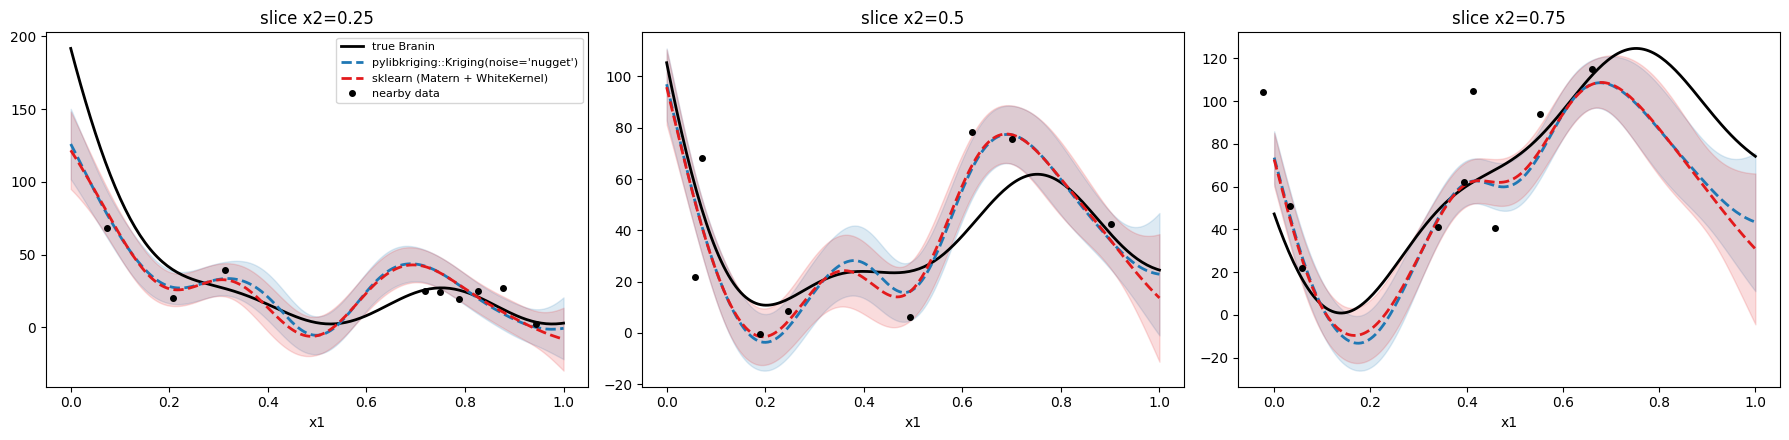

In [8]:
models_noisy = [
    ("pylibkriging::Kriging(noise='nugget')",
     lambda Xs: (k_lk_noisy.predict(Xs, True, False, False)[0].flatten(),
                 k_lk_noisy.predict(Xs, True, False, False)[1].flatten())),
    ("sklearn (Matern + WhiteKernel)",
     lambda Xs: (gp_noisy.predict(Xs, return_std=True)[0].flatten(),
                 gp_noisy.predict(Xs, return_std=True)[1].flatten())),
]
plot_slices(models_noisy, data=(X_noisy, y_noisy))


Both packages recover a very similar noise standard deviation, close to the
true injected value, and both produce a *smoothed* fit that no longer
interpolates the noisy observations exactly -- unlike the noise-free
mimicry fit in Section 3, the predicted mean now passes near, rather than
through, individual data points, and the uncertainty ribbon no longer
shrinks to zero at the training locations. This is the expected behaviour
of a properly estimated (rather than merely fixed/known) observation-noise
level, and `pylibkriging`'s `noise="nugget"` plays exactly the same role as
sklearn's additive, MLE-estimated `WhiteKernel`.


## 5. Argument correspondence table

| scikit-learn | pylibkriging equivalent | Notes |
|---|---|---|
| `Matern(nu=2.5, length_scale=[...])` | `kernel="matern5_2"` | also `nu=1.5` -> `"matern3_2"`; `RBF()` -> `"gauss"`; length-scale is per dimension (ARD) in both |
| `ConstantKernel(c) * Matern(...)` | *(implicit)* | pylibkriging always estimates the process variance `sigma2` internally; no separate amplitude kernel needed |
| constant `mean_function` (no explicit trend term; sklearn assumes zero mean unless `normalize_y`) | `regmodel="constant"` | also `"linear"`, `"quadratic"` |
| `alpha=<value or vector>` | `noise=<value or vector>` (on `Kriging`) | *known/fixed* observation-noise variance in both |
| `+ WhiteKernel(noise_level=...)` (estimated by MLE) | `noise="nugget"` | *estimated*, homogeneous observation-noise variance in both |
| `n_restarts_optimizer=k` | `optim="BFGSk"` (e.g. `"BFGS10"`) | number of independent optimizer restarts |
| `.fit(X, y)` | constructor `Kriging(y, X, ...)` | pylibkriging fits at construction time |
| `.predict(Xnew, return_std=True)` | `.predict(Xnew, return_stdev=True, ...)` | returns `(mean, stdev)` in both |
| `gp.kernel_` | `.theta()`, `.sigma2()`, `.nugget()` | different parameterisations of the same Matern kernel |

See `skills/libkriging/SKILL.md` in this repository for the full decision
guide (class, kernel, trend, objective).
